# Lasso Regression Implementation

Lasso (Least Absolute Shrinkage and Selection Operator) là một phương pháp hồi quy tuyến tính sử dụng kỹ thuật điều chuẩn L1.
Ưu điểm của Lasso:

-   Thực hiện lựa chọn biến tự động bằng cách đưa một số hệ số về 0
-   Giảm overfitting
-   Xử lý tốt hiện tượng đa cộng tuyến (multicollinearity)

Trong phần này, chúng ta sẽ huấn luyện mô hình Lasso và so sánh với mô hình Gradient Boosting.


In [12]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from sklearn.model_selection import KFold, train_test_split
import json

def target_encode_kfold(df, column, target, n_fold=5, alpha=5):
    """
    Performs target encoding with k-fold cross-validation to prevent data leakage.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe containing the data
    column : str
        The name of the categorical column to encode
    target : str
        The name of the target column
    n_fold : int, default=5
        Number of folds for cross-validation
    alpha : float, default=5
        Regularization parameter
        
    Returns:
    --------
    pandas Series
        The encoded values for the column
    """
    # Create a copy of the dataframe
    df_copy = df.copy()
    
    # Calculate the global mean
    global_mean = df_copy[target].mean()
    
    # Create the output Series
    encoded = pd.Series(index=df_copy.index)
    
    # Split the data into n_fold parts
    kf = KFold(n_splits=n_fold, shuffle=True, random_state=42)
    
    for train_idx, test_idx in kf.split(df_copy):
        # Calculate the mean target for each category in the training fold
        means = df_copy.iloc[train_idx].groupby(column)[target].agg(['mean', 'count'])
        
        # Apply regularization
        smoothed_means = ((means['mean'] * means['count']) + (global_mean * alpha)) / (means['count'] + alpha)
        
        # Map the means to the test fold
        encoded.iloc[test_idx] = df_copy.iloc[test_idx][column].map(smoothed_means)
    
    # Handle any categories that weren't seen in the training data (use global mean)
    encoded.fillna(global_mean, inplace=True)
    
    return encoded

# Đọc dữ liệu đã mã hóa
train_file = '../../data/datasets/train_stratified_by_chip_model.csv'
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

# Các cột cần encoding và cột mục tiêu
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']
target_col = 'price'

# Lấy encoding_means từ file nếu có hoặc tạo mới
try:
    with open('./encoding_means.json', 'r') as f:
        encoding_means = json.load(f)
    print("Loaded existing encoding means")
    
    # Áp dụng encoding từ file đã có
    for col in categorical_cols:
        if f'{col}_encoded' not in train_df.columns:
            train_df[f'{col}_encoded'] = train_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())
        if f'{col}_encoded' not in test_df.columns:
            test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())
except:
    # Nếu chưa có encoding, thực hiện lại quá trình encoding
    encoding_means = {}
    for col in categorical_cols:
        print(f"Encoding {col}...")
        train_df[f'{col}_encoded'] = target_encode_kfold(
            train_df, column=col, target=target_col, n_fold=5, alpha=10
        )
        # Lưu mean của từng category
        encoding_means[col] = train_df.groupby(col)[f'{col}_encoded'].mean().to_dict()
        # Áp dụng encoding cho tập test
        test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())
    
    # Lưu encoding_means vào file JSON
    with open('./datasets/encoding_means.json', 'w') as f:
        json.dump(encoding_means, f)

# Các cột đặc trưng và biến mục tiêu
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
target = 'price'

print(f"Features: {features}")

# Chuẩn bị dữ liệu
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Chuẩn hóa dữ liệu (quan trọng đối với Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lựa chọn alpha tối ưu bằng cross-validation
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
optimal_alpha = lasso_cv.alpha_
print(f"Optimal alpha value: {optimal_alpha}")

# Huấn luyện mô hình Lasso với alpha tối ưu
lasso_model = Lasso(
    alpha=optimal_alpha,
    random_state=42,
    max_iter=10000,
    positive=True,
    tol=0.000001,
    selection="cyclic"
)
lasso_model.fit(X_train_scaled, y_train)
print("lasso score ", lasso_model.score) 

# Lưu mô hình vào file
joblib.dump(lasso_model, 'lasso_model.pkl')
# Lưu scaler để sử dụng khi dự đoán
joblib.dump(scaler, 'scaler_for_lasso.pkl')
print("Saved Lasso model to 'lasso_model.pkl'")

# Dự đoán trên tập test
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Đánh giá mô hình Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Mean Absolute Error (MAE): {mae_lasso}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso}")
print(f"R² Score: {r2_lasso}")

Loaded existing encoding means
Features: ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 'camera_main_resolution', 'camera_count', 'chip_model_encoded', 'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
Optimal alpha value: 72750.5248400071
lasso score  <bound method RegressorMixin.score of Lasso(alpha=np.float64(72750.5248400071), max_iter=10000, positive=True,
      random_state=42, tol=1e-06)>
Saved Lasso model to 'lasso_model.pkl'
Mean Absolute Error (MAE): 2981984.2371231504
Root Mean Squared Error (RMSE): 4127239.665534677
R² Score: 0.7628687812086969


## Trực quan hóa quá trình huấn luyện Lasso

Dưới đây là các biểu đồ giúp hiểu rõ hơn về quá trình huấn luyện mô hình Lasso và cách hoạt động của regularization.


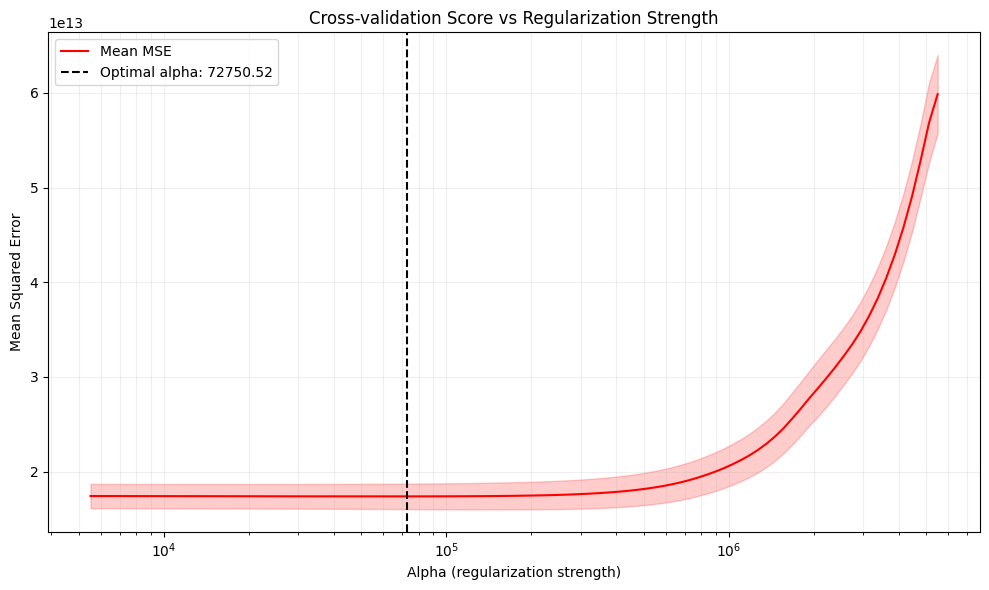

Optimal alpha selected: 72750.52484


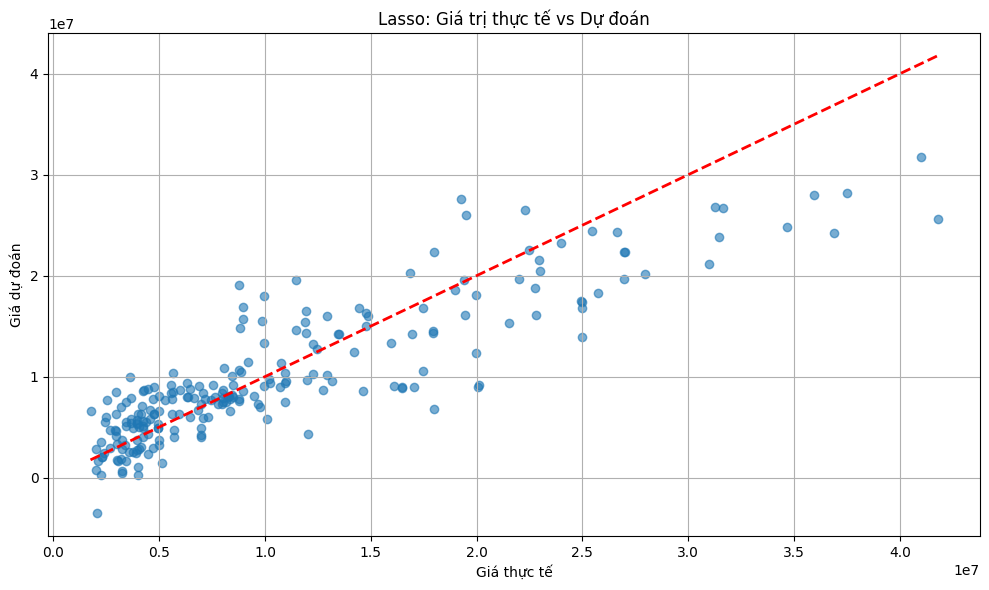

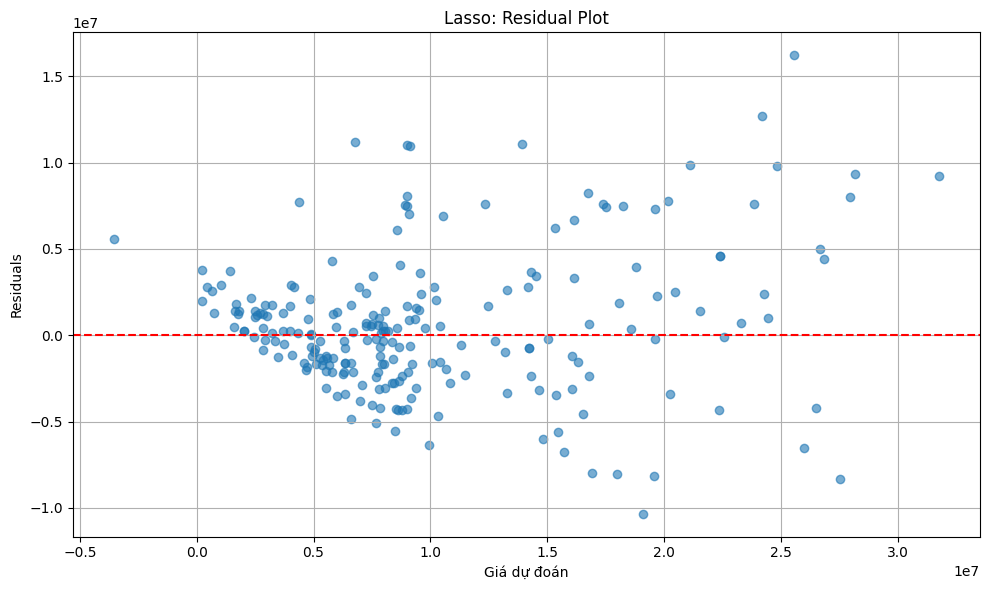

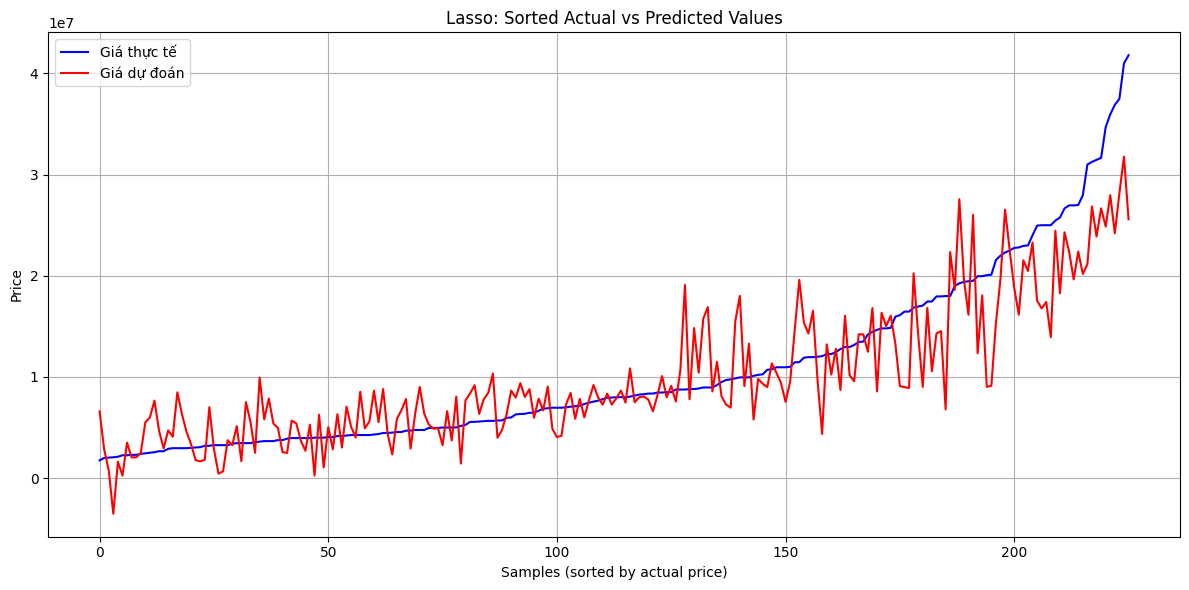

Các metrics đánh giá mô hình Lasso:


,Metric,Value
0,MAE,2.981984e+06
1,RMSE,4.127240e+06
2,R²,7.628688e-01


In [14]:
# Import thêm thư viện seaborn nếu cần
try:
    import seaborn as sns
except ImportError:
    print("Seaborn không được cài đặt. Một số biểu đồ có thể không hiển thị.")

# Trực quan hóa quá trình huấn luyện Lasso

# 1. Visualize the alpha selection process if available
try:
    # Lấy các alpha được thử nghiệm trong LassoCV
    alphas = lasso_cv.alphas_
    
    # Cross-validation scores
    mse_path = lasso_cv.mse_path_
    mean_mse = np.mean(mse_path, axis=1)
    std_mse = np.std(mse_path, axis=1) / np.sqrt(mse_path.shape[1])
    
    plt.figure(figsize=(10, 6))
    plt.semilogx(alphas, mean_mse, 'r-', label='Mean MSE')
    plt.fill_between(alphas, mean_mse - std_mse, mean_mse + std_mse, alpha=0.2, color='r')
    plt.axvline(optimal_alpha, color='black', linestyle='--', label=f'Optimal alpha: {optimal_alpha:.2f}')
    
    plt.xlabel('Alpha (regularization strength)')
    plt.ylabel('Mean Squared Error')
    plt.title('Cross-validation Score vs Regularization Strength')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    print(f"Optimal alpha selected: {optimal_alpha:.5f}")
    
except (AttributeError, ValueError) as e:
    print(f"Không thể vẽ biểu đồ chọn alpha: {e}")

# 2. Visualize actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('Lasso: Giá trị thực tế vs Dự đoán')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Visualize residuals
residuals = y_test - y_pred_lasso
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_lasso, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá dự đoán')
plt.ylabel('Residuals')
plt.title('Lasso: Residual Plot')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Visualize sorted predictions vs actual values
indices = np.argsort(y_test)
sorted_y_test = y_test.iloc[indices].values
sorted_y_pred = y_pred_lasso[indices]

plt.figure(figsize=(12, 6))
plt.plot(range(len(sorted_y_test)), sorted_y_test, 'b-', label='Giá thực tế')
plt.plot(range(len(sorted_y_pred)), sorted_y_pred, 'r-', label='Giá dự đoán')
plt.xlabel('Samples (sorted by actual price)')
plt.ylabel('Price')
plt.title('Lasso: Sorted Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Display metrics in a formatted table
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae_lasso, rmse_lasso, r2_lasso]
})

print("Các metrics đánh giá mô hình Lasso:")
display(metrics_df)

## Trực quan hóa kết quả và phân tích Lasso Regression

### 1. Hệ số mô hình Lasso

Phân tích các hệ số (coefficients) của mô hình Lasso để xem các đặc trưng nào quan trọng và đặc trưng nào bị loại bỏ (hệ số = 0).


Số đặc trưng bị loại bỏ (hệ số = 0): 2 / 10

Top các đặc trưng quan trọng:


,Feature,Coefficient,Absolute_Coefficient
6,chip_model_encoded,2.225764e+06,2.225764e+06
7,brand_encoded,2.053445e+06,2.053445e+06
8,screen_tech_encoded,1.971987e+06,1.971987e+06
2,screen_size,1.563120e+06,1.563120e+06
9,screen_resolution_k_encoded,1.129748e+06,1.129748e+06


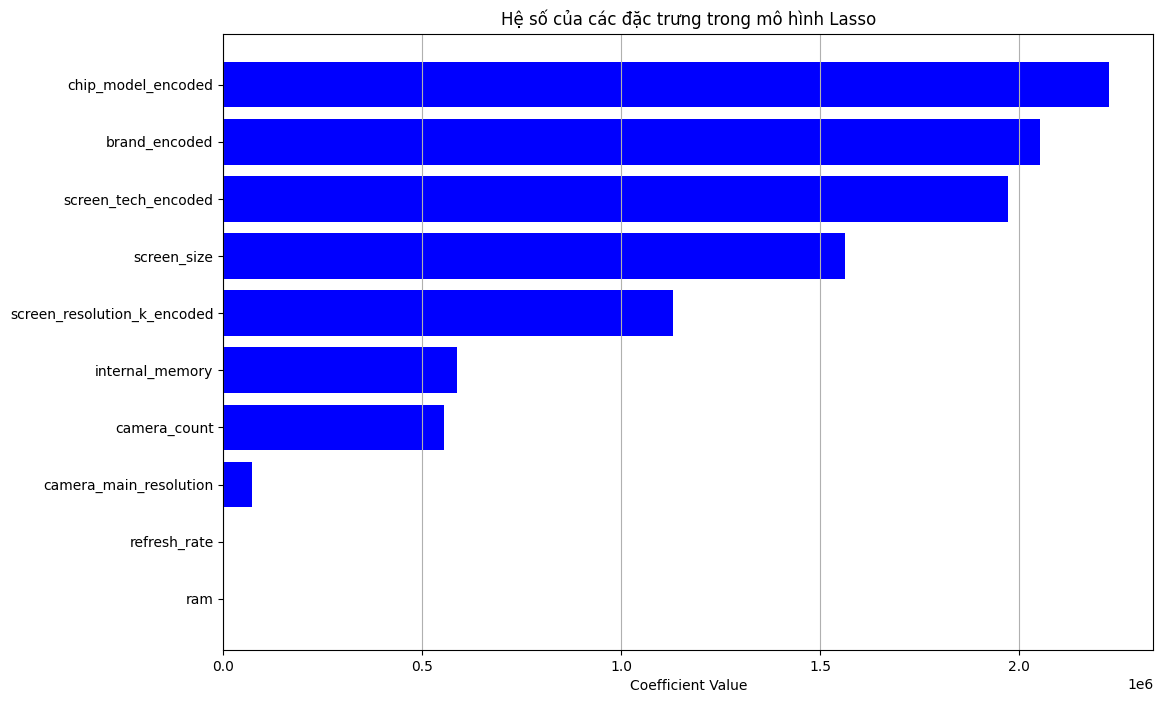

In [11]:
# Hiển thị các hệ số của mô hình Lasso
coefs = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso_model.coef_
})

# Sắp xếp theo giá trị tuyệt đối của hệ số để thấy đặc trưng quan trọng nhất
coefs['Absolute_Coefficient'] = np.abs(coefs['Coefficient'])
coefs = coefs.sort_values(by='Absolute_Coefficient', ascending=False)

# Số đặc trưng bị loại bỏ (hệ số = 0)
zero_coefs = sum(coefs['Coefficient'] == 0)
print(f"Số đặc trưng bị loại bỏ (hệ số = 0): {zero_coefs} / {len(features)}")

print("\nTop các đặc trưng quan trọng:")
display(coefs.head())

# Trực quan hóa hệ số
plt.figure(figsize=(12, 8))
coefs = coefs.sort_values(by='Coefficient')
colors = ['red' if c < 0 else 'blue' for c in coefs['Coefficient']]
plt.barh(coefs['Feature'], coefs['Coefficient'], color=colors)
plt.title('Hệ số của các đặc trưng trong mô hình Lasso')
plt.xlabel('Coefficient Value')
plt.grid(axis='x')
plt.show()

### 2. So sánh mô hình Lasso với Gradient Boosting

Biểu đồ so sánh giá trị thực tế và dự đoán giữa hai mô hình.


Không thể tải mô hình Gradient Boosting: <class 'numpy.random._mt19937.MT19937'> is not a known BitGenerator module.


C:\Users\vulin\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Model,MAE,RMSE,R²
0,Lasso Regression,2.982102e+06,4.127144e+06,0.76288


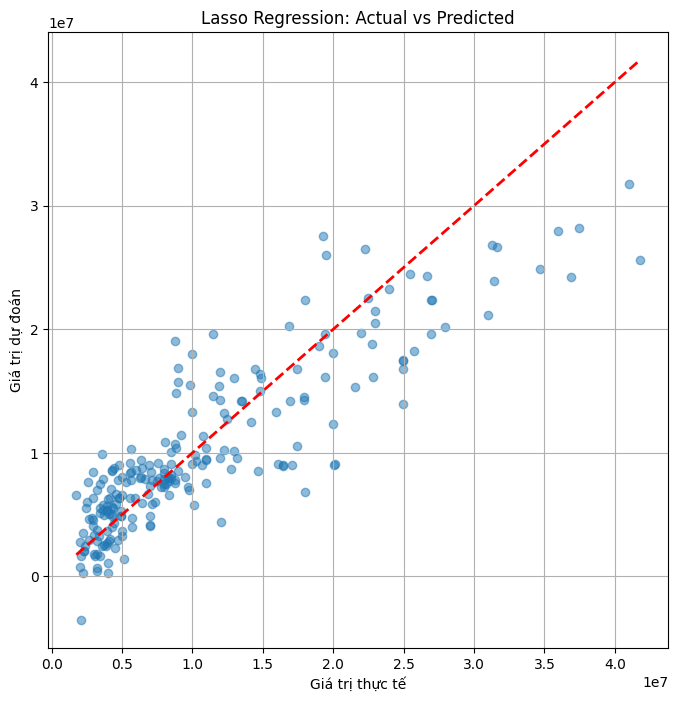

In [23]:
# Lấy dự đoán từ mô hình Gradient Boosting nếu có
try:
    gb_model = joblib.load('../GradientBoosting/best_gb_model.pkl')
    y_pred_gb = gb_model.predict(X_test)
    
    # Tính metrics cho Gradient Boosting
    mae_gb = mean_absolute_error(y_test, y_pred_gb)
    rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
    r2_gb = r2_score(y_test, y_pred_gb)
    
    # So sánh metrics
    metrics_comparison = pd.DataFrame({
        'Model': ['Lasso Regression', 'Gradient Boosting'],
        'MAE': [mae_lasso, mae_gb],
        'RMSE': [rmse_lasso, rmse_gb],
        'R²': [r2_lasso, r2_gb]
    })
    
    display(metrics_comparison)
    
    # Trực quan hóa so sánh dự đoán
    plt.figure(figsize=(12, 8))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred_lasso, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Giá trị thực tế')
    plt.ylabel('Giá trị dự đoán')
    plt.title('Lasso Regression')
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred_gb, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Giá trị thực tế')
    plt.ylabel('Giá trị dự đoán')
    plt.title('Gradient Boosting')
    plt.grid()
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Không thể tải mô hình Gradient Boosting: {e}")
    
    # Chỉ hiển thị kết quả của Lasso
    metrics_lasso = pd.DataFrame({
        'Model': ['Lasso Regression'],
        'MAE': [mae_lasso],
        'RMSE': [rmse_lasso],
        'R²': [r2_lasso]
    })
    
    display(metrics_lasso)
    
    # Chỉ vẽ biểu đồ cho Lasso
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_pred_lasso, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Giá trị thực tế')
    plt.ylabel('Giá trị dự đoán')
    plt.title('Lasso Regression: Actual vs Predicted')
    plt.grid()
    plt.show()